# Built-in Qubricks in Workbench

In this tutorial, we will learn about miscellaneous built-in Qubricks provided by Workbench.

Earlier, in the [tutorial on quantum arithmetic](./Quantum-Arithmetic.ipynb), we went through quite a few built-in Qubricks that implement common arithmetic operations, bitwise operations, and comparisons.
In this tutorial, we will continue the discussion by covering more built-in Qubricks Workbench offers for more advanced mathematical computations and commonly used tools such as QFT, reflection, and state preparation.

> The Qubricks listed here are not an exhaustive list of libraries offered by Workbench! You can find more Qubricks in [Workbench Algorithms](https://construct.psiquantum.com/docs/psiqdk-algorithms/index.html).

## Reflect

Reflection is the operation of selecting one basis state and applying a relative phase to it, leaving other basis states unchanged. This operation implements reflection about a state, hence the name. This operation is implemented as the `Reflect` Qubrick. It is also available as the `reflect` method of the Qubits register (see [Basic Gates tutorial](./Basic-Gates.ipynb#reflect-operation)); in fact, that method calls the `Reflect` Qubrick under the hood.

The following example shows how to implement the first `reflect` example from the [Basic Gates tutorial](./Basic-Gates.ipynb#reflect-operation) using a Qubrick instead of the `reflect` method.

|reg>
|0>    -0.353553-0.000000j
|1>    0.000000+0.353553j
|2>    0.353553+0.000000j
|3>    0.250000+0.250000j
|4>    0.353553+0.000000j
|5>    0.353553+0.000000j
|6>    0.353553+0.000000j
|7>    -0.353553-0.000000j


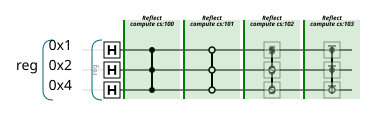

In [1]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.rotations import Reflect

qpu = QPU(num_qubits=3)
reg = Qubits(3, "reg", qpu)
reg.had()

refl = Reflect()

# Multiply |111⟩ by -1
refl.compute(reg)

# Multiply |000⟩ by -1
refl.compute(~reg)

# Multiply |100⟩ by i
refl.compute(reg[0] | ~reg[1:], theta=90)

# Multiply |110⟩ by e^(iπ/4)
refl.compute(reg==3, theta=(1, 4))

qpu.print_state_vector()

qpu.draw(show_qubricks=True)

## Uniform state preparation

Uniform state preparation is the task of transforming a Qubits register in the $|0\rangle$ state into an equal superposition of the first $d$ basis states:

$$|0\rangle \rightarrow \sum_{k=0}^{d-1} \frac{1}{\sqrt{d}}|k\rangle$$

Workbench offers several built-in Qubricks that implement different algorithms for uniform state preparation (see [Uniform State Preparation Qubricks](https://construct.psiquantum.com/docs/psiqdk-workbench/reference/reference_qubricks_usp.html)). The following code snippet shows how to use two of them: `USP`, which allocates additional qubits to prepare the state, and `ZAUSP`, which prepares the state using zero auxiliary qubits (thus the name).

|reg|qbk_usp>
|0|0>    -0.192450+0.272166j
|0|1>    -0.192450+0.272166j
|0|2>    -0.192450+0.272166j
|1|0>    -0.192450+0.272166j
|1|1>    -0.192450+0.272166j
|1|2>    -0.192450+0.272166j
|2|0>    -0.192450+0.272166j
|2|1>    -0.192450+0.272166j
|2|2>    -0.192450+0.272166j


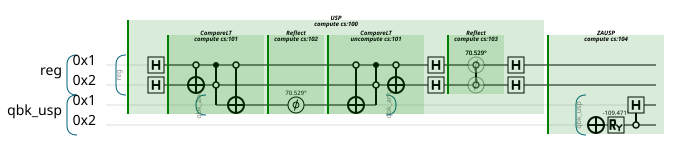

In [2]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.usp import USP, ZAUSP
qpu = QPU(num_qubits=4)
reg = Qubits(2, "reg", qpu)

# Prepare a uniform state on already allocated register
USP().compute(3, reg)

# Allocate a new register and prepare a uniform state on it
ZAUSP(qc=qpu).compute(3)

qpu.print_state_vector()
qpu.draw(show_qubricks=True)

## Quantum Fourier transform

Quantum Fourier transform is an extremely common routine in quantum algorithms. In Workbench, it is implemented using the [`QFT` Qubrick](https://construct.psiquantum.com/docs/psiqdk-workbench/reference/reference_qubricks_simple.html#psiqdk.workbench.qft.QFT). As usual in Workbench, QFT uses little-endian notation for converting basis states to integers used in QFT formulas.

The following code snippet shows how to use QFT to convert the basis state $|010\rangle$ to the following superposition state with periodic relative phase:

$$\tfrac1{2\sqrt2}\sum_{k=0}^{7} e^{i\pi \cdot k/2} |k\rangle =$$
$$\tfrac1{2\sqrt2}(|000\rangle + i|100\rangle - |010\rangle -i|110\rangle + |001\rangle + i|101\rangle - |011\rangle -i|111\rangle)$$

|reg>
|0>    0.353553+0.000000j
|1>    0.000000+0.353553j
|2>    -0.353553+0.000000j
|3>    -0.000000-0.353553j
|4>    0.353553+0.000000j
|5>    0.000000+0.353553j
|6>    -0.353553+0.000000j
|7>    -0.000000-0.353553j


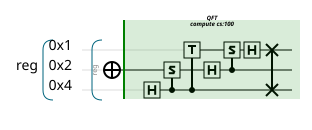

In [3]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.qft import QFT

qpu = QPU(num_qubits=3)
reg = Qubits(3, "reg", qpu)

reg[1].x()

QFT().compute(reg)

qpu.print_state_vector()
qpu.draw(show_qubricks=True)

## QFT-based arithmetic

Workbench offers several Qubricks that implement [QFT-based arithmetic](https://construct.psiquantum.com/docs/psiqdk-workbench/reference/reference_qubricks_qft_arithmetic.html): increment by a constant, addition, subtraction and multiplication. Unlike [other built-in arithmetic Qubricks](./Quantum-Arithmetic.ipynb), these Qubricks only support `QUInt` data type. Increment, addition, and subtraction are done in-place, while multiplication allocates a new register to store and return its result.

The following example shows how to use QFT-based arithmetic Qubricks.

> Notice that QFT addition is not modular; it will handle overflow by extending the target register. In the example below, the sum of `reg1` and `reg2` is greater than the maximal number that can be stored in the two-qubit register `reg1`, so the result register has three qubits: `reg1` and the extra qubit `tmp` that stores the most significant bit of the sum.

|reg1|?>
|3|.>    1.000000-0.000000j
|reg1|reg2|?>
|3|2|.>    1.000000-0.000000j
|reg1|reg2|tmp>
|1|2|1>    1.000000-0.000000j
5


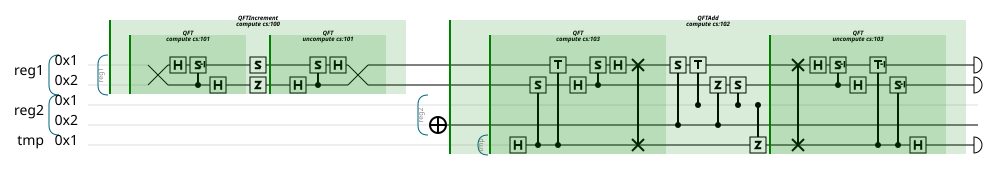

In [4]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.arithmetic import QFTAdd, QFTIncrement

qpu = QPU(num_qubits=5)
reg1 = Qubits(2, "reg1", qpu)

QFTIncrement().compute(reg1, 3)
qpu.print_state_vector()

reg2 = Qubits(2, "reg2", qpu)
reg2[1].x()
qpu.print_state_vector()

adder = QFTAdd()
adder.compute(reg1, reg2)
res = adder.get_result_qreg()
qpu.print_state_vector()
print(res.read())

qpu.draw(show_qubricks=True)

## Square root

The Qubrick `Sqrt` implements the square root function. It takes a `QUInt` input and calculates two result values:

* The integer part of the square root $\lfloor \sqrt{x} \rfloor$ is returned as the "default" result of the computation and can be retrieved using `get_result_qreg()` call without result name. 
* The remainder (the value $x - \lfloor \sqrt{x} \rfloor^2$) can be retrieved using `get_result_qreg("remainder")`.

The following example shows how to use the `Sqrt` Qubrick to compute the square root and the remainder.

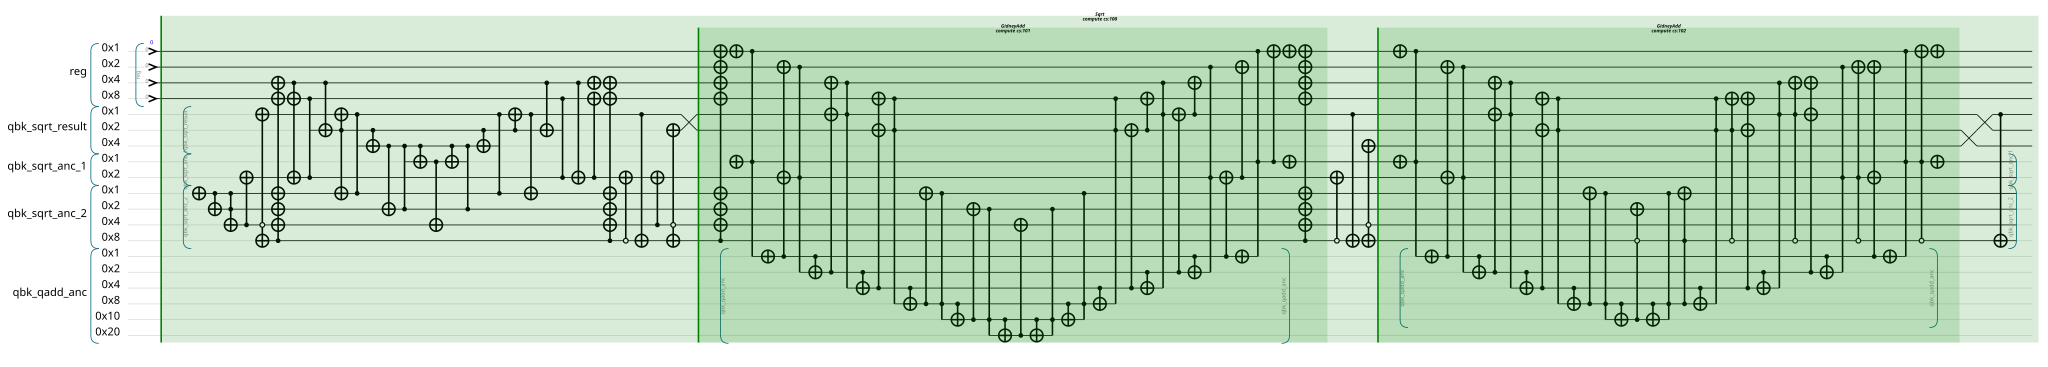

|  x  | sqrt(x) | Sqrt | Remainder |
|   0 | 0.000   |  0   | 0         |
|   1 | 1.000   |  1   | 0         |
|   2 | 1.414   |  1   | 1         |
|   3 | 1.732   |  1   | 2         |
|   4 | 2.000   |  2   | 0         |
|   5 | 2.236   |  2   | 1         |
|   6 | 2.449   |  2   | 2         |
|   7 | 2.646   |  2   | 3         |
|   8 | 2.828   |  2   | 4         |
|   9 | 3.000   |  3   | 0         |
|  10 | 3.162   |  3   | 1         |
|  11 | 3.317   |  3   | 2         |
|  12 | 3.464   |  3   | 3         |
|  13 | 3.606   |  3   | 4         |


|  14 | 3.742   |  3   | 5         |

|  15 | 3.873   |  3   | 6         |

In [5]:
from math import sqrt
from psiqdk.workbench import QPU, QUInt
from psiqdk.workbench.arithmetic import Sqrt

qpu = QPU()
for val in range(16):
    qpu.reset(19)

    reg = QUInt(4, "reg", qpu)
    reg.write(val)

    qbk_sqrt = Sqrt()
    qbk_sqrt.compute(reg)
    res_main = qbk_sqrt.get_result_qreg()
    res_rem = qbk_sqrt.get_result_qreg("remainder")

    if val == 0:
        qpu.draw(show_qubricks=True)
        print("|  x  | sqrt(x) | Sqrt | Remainder |")

    print(f"| {str(val).rjust(3)} | {sqrt(val):.3f}   |  {res_main.read()}   | {res_rem.read()}         |")


## Applying a unitary described as a matrix

On a real quantum device, the only way to apply a unitary to a quantum register is through applying a sequence of gates. When running on a simulator, though, you can apply a unitary to the quantum state directly, by multiplying it by the corresponding matrix. (This is similar to how you can set the quantum state directly using the `push_state` method of the Qubits register.) To do this, you can use the `Matrix` Qubrick.

The following example demonstrates the use of the `Matrix` Qubrick. It defines a single-qubit matrix similar to that of the $Ry$ gate (up to the relative phase of the second column) and a two-qubit matrix that describes its controlled variant, and then applies these matrices to a single-qubit and a two-qubit register, respectively.

In [6]:
from numpy import array
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.utils.matrix import Matrix

qpu = QPU(num_qubits=2)
reg = Qubits(2, "reg", qpu)

reg.push_state([0.6, 0, 0, 0.8])
qpu.print_state_vector()

m = array([[0.6, 0.8],
           [0.8, -0.6]])

apply_matrix = Matrix()
# Apply the matrix to the least significant bit
apply_matrix.compute(m, reg[0])
qpu.print_state_vector()

# Shape of the same matrix controlled on the most significant bit
controlled_m = array([[1, 0, 0, 0],
                      [0, 1, 0, 0],
                      [0, 0, 0.6, 0.8],
                      [0, 0, 0.8, -0.6]])
apply_matrix.compute(controlled_m, reg)
_ = qpu.print_state_vector()

|reg>
|0>    0.600000+0.000000j
|3>    0.800000+0.000000j
|reg>
|0>    0.360000+0.000000j
|1>    0.480000+0.000000j
|2>    0.640000+0.000000j
|3>    -0.480000+0.000000j
|reg>
|0>    0.360000+0.000000j
|1>    0.480000+0.000000j
|3>    0.800000+0.000000j


## Next steps

In this tutorial, you've learned about additional built-in Qubricks in Workbench. Remember, you can access more library Qubricks via [Workbench Algorithms](https://construct.psiquantum.com/docs/psiqdk-algorithms/index.html)!